In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
rfm = pd.read_csv('../data/processed/rfm_clientes.csv')
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


In [4]:
# Separando apenas os dados numéricos
X = rfm[['Recency', 'Frequency', 'Monetary']]

In [5]:
# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Fazer o método cotovelo para encontrar o número ideal de clusters
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

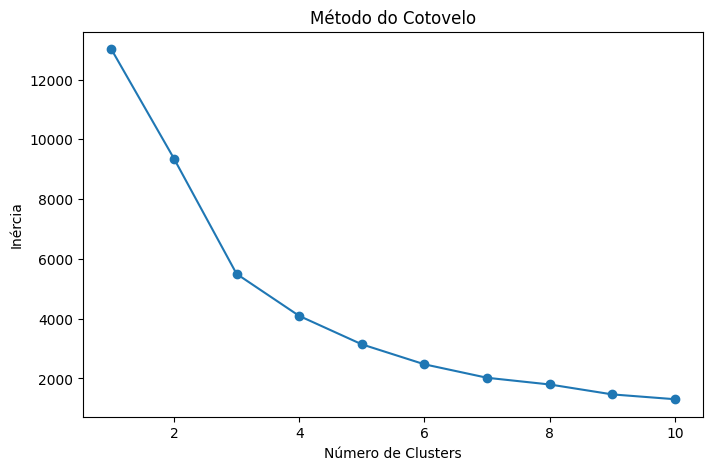

In [7]:
# Mostrando o gráfico do método cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.savefig('../imagens/metodo_cotovelo.png')
plt.show()

In [8]:
# Treinando o modelo KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,325,1,77183.60,3
1,12347,1,7,4310.00,0
2,12348,74,4,1797.24,0
3,12349,18,1,1757.55,0
4,12350,309,1,334.40,1


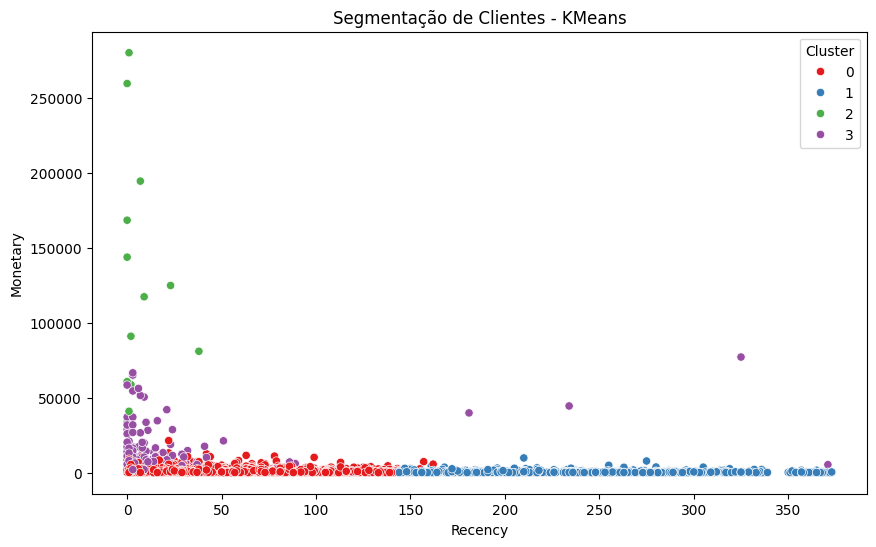

In [9]:
# Gerando o gráfico de dispersão dos clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette='Set1'
)
plt.title('Segmentação de Clientes - KMeans')
plt.savefig('../imagens/segmentacao_kmeans.png')
plt.show()

In [14]:
# Analisar os clusters
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

In [12]:
print(cluster_summary)

           CustomerID     Recency  Frequency       Monetary
Cluster                                                    
0        15289.128356   42.702685   3.682711    1359.049284
1        15347.791940  247.075914   1.552015     480.617480
2        15435.000000    6.384615  82.538462  127338.313846
3        15212.857843   14.500000  22.333333   12709.090490


In [13]:
# Salvar a base final
rfm.to_csv('../data/processed/rfm_clientes_segmentados.csv', index=False)